<a href="https://colab.research.google.com/github/dani-loya/Diabetes-Readmission-ML-DL-Framework/blob/main/ADS504_Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**`Predicting 30-Day Hospital Readmission in Diabetic Patients`**



Author: Danitza Loya https://github.com/dani-loya/Diabetes-Readmission-ML-DL-Framework

Final Project Colab Link : https://colab.research.google.com/drive/1RJ00G_pOc0XxV-j_q0k2_nmc0q4LJpXF?usp=sharing



Dataset: UCI Diabetes 130-US Hospitals (1999-2008)

This project focuses on hospital readmissions within 30 days because this unplanned returns result in major clinical and financial burden for the patients. I am trying to optimize a machine learning framework to identify high-risk diabetic patients before discharge, so the patients can walk away prepare with their plan in hand such as next appointment, clear review of mediations, etc.

In [ ]:
# Find CSV to add into Colab
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data (2).csv


In [ ]:
# Import all libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_recall_curve, classification_report,accuracy_score, recall_score, precision_score, f1_score, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load and define the diabetic dataset (130-US Hospitals 1999-2008)
df = pd.read_csv('/content/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


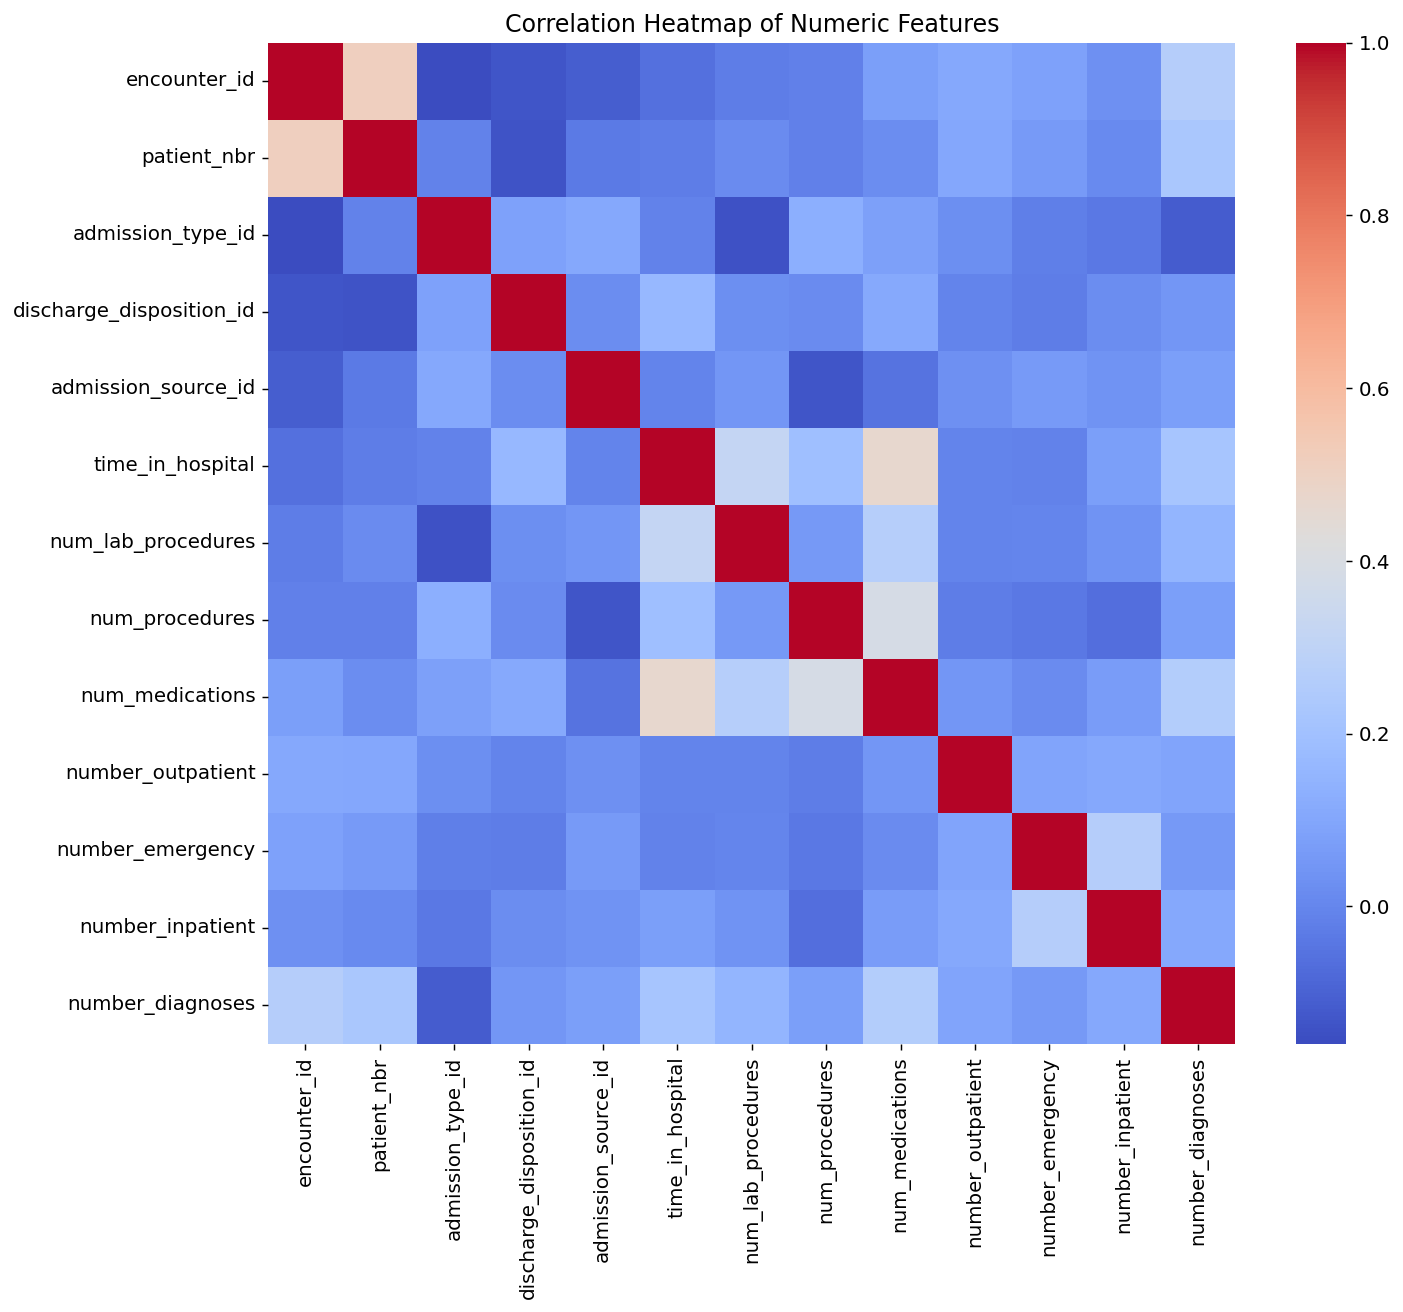

In [ ]:
# Correlation heatmap (Numeric)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
# Inspect column types, missing values and statistics summary per columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


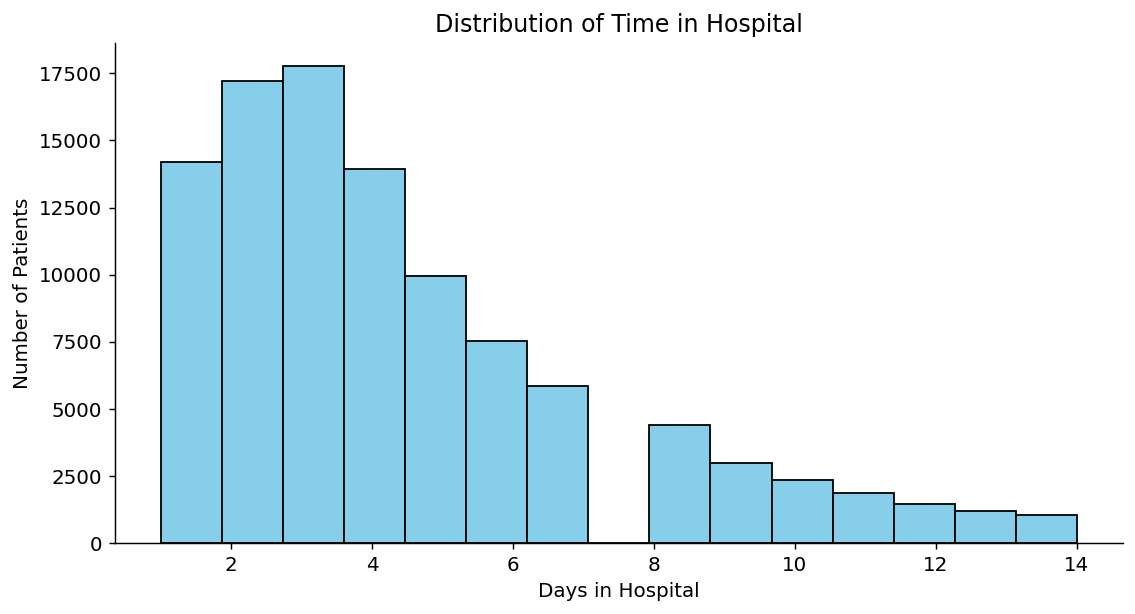

In [ ]:
# Distribution of Time in Hospital
plt.figure(figsize=(10,5))
plt.hist(df['time_in_hospital'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Time in Hospital')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.show()

In [ ]:
# Calculate the percentage of missingness
df.isnull().sum() / len(df) * 100

,0
encounter_id,0.000000
patient_nbr,0.000000
race,0.000000
gender,0.000000
age,0.000000
weight,0.000000
admission_type_id,0.000000
discharge_disposition_id,0.000000
admission_source_id,0.000000
time_in_hospital,0.000000


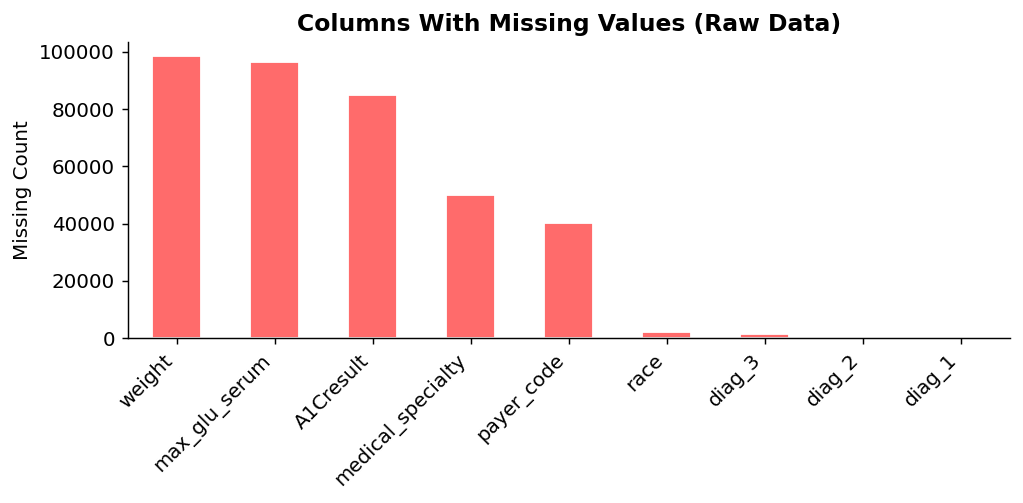

weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02


In [ ]:
# Missingness values analysis bar chart
df_raw = pd.read_csv('/content/diabetic_data.csv').replace('?', np.nan)
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='#ff6b6b', edgecolor='white')
plt.title('Columns With Missing Values (Raw Data)', fontsize=13, fontweight='bold')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print percentage table
pct = (missing / len(df_raw) * 100).round(2).rename('Missing %')
print(pct.to_string())

del df_raw

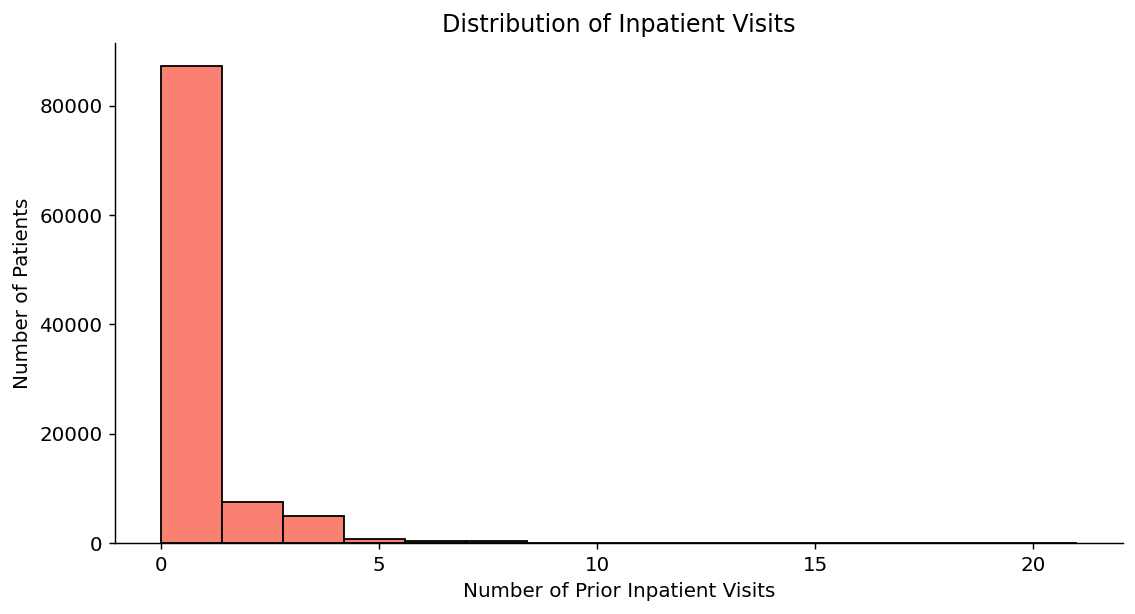

In [ ]:
# Distribution of inpatient visits
plt.figure(figsize=(10,5))
plt.hist(df['number_inpatient'], bins=15, color='salmon', edgecolor='black')
plt.title('Distribution of Inpatient Visits')
plt.xlabel('Number of Prior Inpatient Visits')
plt.ylabel('Number of Patients')
plt.show()

**Pre-processing**

In [ ]:
# Clean column names by fixing accidental spaces
df.columns = df.columns.str.strip()

In [ ]:
# Replace "?" with NaN
df.replace("?", np.nan, inplace=True)

In [ ]:
# Add binary indicators for missingness
df['max_glu_serum_missing'] = df['max_glu_serum'].isna().astype(int)
df['A1Cresult_missing'] = df['A1Cresult'].isna().astype(int)

# Drop the original sparse columns
df.drop(['max_glu_serum', 'A1Cresult'], axis=1, inplace=True)

In [ ]:
# Convert AGE ranges to numeric midpoints
def convert_age(age_str):
    age_str = str(age_str)
    nums = re.findall(r'\d+', age_str)
    if len(nums) == 2:
        low, high = map(int, nums)
        return (low + high) / 2
    return np.nan

df['age'] = df['age'].apply(convert_age)

In [ ]:
# Convert weight ranges to numeric midpoint
def convert_weight(w):
    w = str(w)
    nums = re.findall(r'\d+', w)
    if len(nums) == 2:
        low, high = map(int, nums)
        return (low + high) / 2
    return np.nan

df['weight'] = df['weight'].apply(convert_weight)

In [ ]:
# Convert diagnosis codes from strings to numeric values
df['diag_1'] = pd.to_numeric(df['diag_1'], errors='coerce')
df['diag_2'] = pd.to_numeric(df['diag_2'], errors='coerce')
df['diag_3'] = pd.to_numeric(df['diag_3'], errors='coerce')

In [ ]:
# Encode readmission TARGET VARIABLE to become binary (readmitted = 1 if readmitted within 30 days and anything else = 0)
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [ ]:
# Encode gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [ ]:
# One-hot encode race (converts race category into multiple binary columns)
df = pd.get_dummies(df, columns=['race'], drop_first=True)

In [ ]:
# Encode medication columns (map medication to numeric values)
med_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone','metformin-rosiglitazone',
    'metformin-pioglitazone'
]

for col in med_cols:
    df[col] = df[col].map({'No':0, 'Steady':1, 'Up':2, 'Down':3})

In [ ]:
# Encode change + diabetesMed (whether meidcation was changed or diabetes medication was prescribed)
df['change'] = df['change'].map({'No':0, 'Ch':1})
df['diabetesMed'] = df['diabetesMed'].map({'No':0, 'Yes':1})

In [ ]:
# One-hot encode for payer_code and medical_specialty
if 'payer_code' in df.columns:
    df = pd.get_dummies(df, columns=['payer_code'], drop_first=True)

if 'medical_specialty' in df.columns:
    df = pd.get_dummies(df, columns=['medical_specialty'], drop_first=True)

In [ ]:
# Drop non-predictive columns
# Encounter id, patient_nbr and readmitted columns are not predictive
for col in ['encounter_id','patient_nbr','readmitted']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [ ]:
# Fill missing values (all missing values with NaN will be replaced with the median of each column)
# Median imputation (good for skewed data)
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# Verify no object columns remain (all columns are now numeric)
print('Remaining object columns:', df.select_dtypes(include=['object']).columns.tolist())
print('Dataset shape:', df.shape)

Remaining object columns: []
Dataset shape: (101766, 136)


**Train / Test and Scaling**

In [ ]:
# Train 80 / Test 20 Split and Scaling
X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 81412
Test size : 20354


SMOTE

In [ ]:
# SMOTE
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: readmitted_binary
0    72326
1     9086
Name: count, dtype: int64
After SMOTE: readmitted_binary
0    72326
1    72326
Name: count, dtype: int64


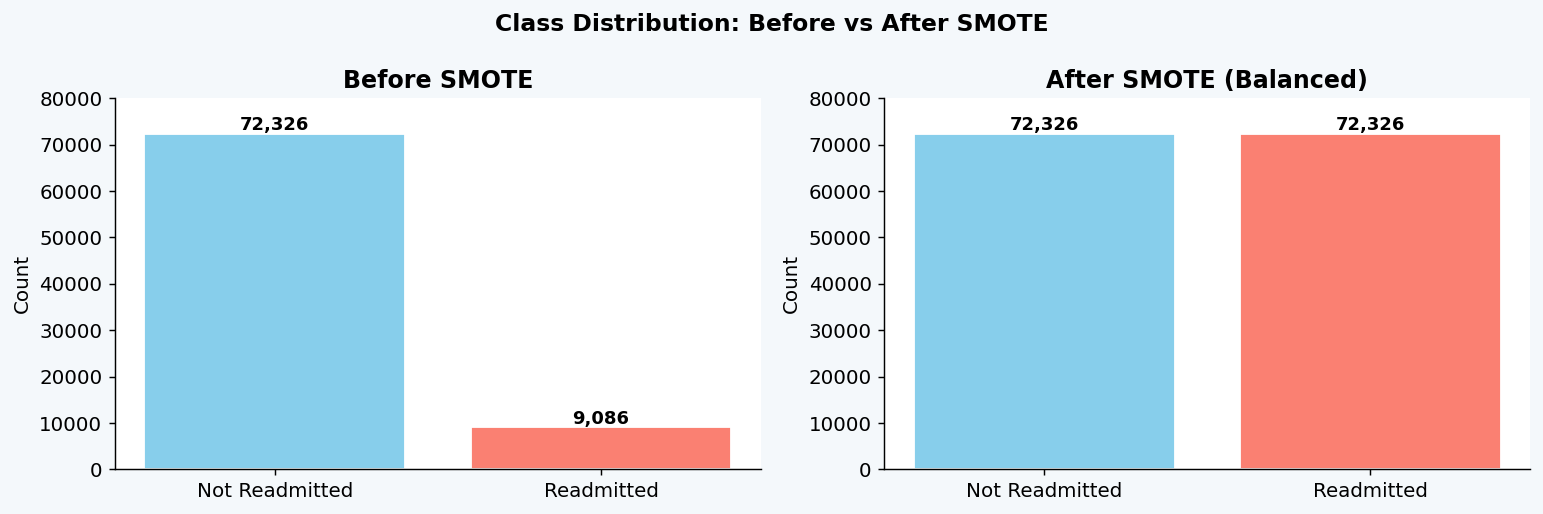

In [ ]:
# Class Distribution Before vs After SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor='#f4f8fb')
fig.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')

labels = ['Not Readmitted', 'Readmitted']
colors = ['skyblue', 'salmon']

# Before
ax1.bar(labels, [72326, 9086], color=colors, edgecolor='white')
ax1.set_title('Before SMOTE', fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, 80000)
for bar, val in zip(ax1.patches, [72326, 9086]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 800,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# After
ax2.bar(labels, [72326, 72326], color=colors, edgecolor='white')
ax2.set_title('After SMOTE (Balanced)', fontweight='bold')
ax2.set_ylabel('Count')
ax2.set_ylim(0, 80000)
for bar, val in zip(ax2.patches, [72326, 72326]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 800,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Supervised Learning Models**

In [ ]:
# Color pallet for all the charts
NAVY  = '#0a1628'
TEAL  = '#00c2b8'
CORAL = '#ff6b6b'
LIGHT = '#f4f8fb'
MUTED = '#8892b0'
GOLD  = '#f4c542'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size'  : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 130,
})
print('Color palette ready')


Color palette ready


In [ ]:
# Train Logistic Regression
log_model_balanced = LogisticRegression(
    max_iter=500,
    class_weight='balanced'
)

# Train on SMOTE-balanced training data
log_model_balanced.fit(X_train_smote, y_train_smote)

# Predict on the original (unmodified) test set
log_preds_balanced = log_model_balanced.predict(X_test_scaled)

# Evaluation
print(classification_report(y_test, log_preds_balanced))
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds_balanced))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18083
           1       0.16      0.55      0.25      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.70     20354

Logistic Regression Accuracy: 0.6365333595362092


In [ ]:
# Train Random Forest
rf_model_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model_balanced.fit(X_train_smote, y_train_smote)
rf_preds_balanced = rf_model_balanced.predict(X_test_scaled)

print(classification_report(y_test, rf_preds_balanced))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds_balanced))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.44      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354

Random Forest Accuracy: 0.887737054141692


In [ ]:
# Train XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)
xgb_preds = xgb.predict(X_test_scaled)

print(classification_report(y_test, xgb_preds))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.64      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.77      0.51      0.49     20354
weighted avg       0.86      0.89      0.84     20354

XGBoost Accuracy: 0.88940748747175


In [ ]:
# Train LightGBM
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train_smote, y_train_smote)
lgb_preds = lgb.predict(X_test_scaled)

print(classification_report(y_test, lgb_preds))
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_preds))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.56      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.73      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354

LightGBM Accuracy: 0.8888670531590842


Evaluation helper functions

In [ ]:
# Scans the precision recall curve to find the decision threshold that maximizes F-2 score ( Recall>precision)
def find_best_threshold(model, X_te, y_te):
    proba = model.predict_proba(X_te)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_te, proba)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-9)
    best_idx = int(np.argmax(f2))
    return float(thresholds[best_idx]), proba

# Converts raw model probabilities into binary predictions using the optimal threshold instead of the default 0.5
def apply_threshold(proba, threshold):
    return (proba >= threshold).astype(int)

# prints a standardized scorecard
def show_metrics(label, y_true, y_pred, proba=None):
    acc = round(accuracy_score(y_true, y_pred) * 100, 2)
    rec = round(recall_score(y_true, y_pred) * 100, 2)
    pre = round(precision_score(y_true, y_pred) * 100, 2)
    f1  = round(f1_score(y_true, y_pred) * 100, 2)
    print('Model     :', label)
    print('Accuracy  :', acc, '%')
    print('Recall    :', rec, '%')
    print('Precision :', pre, '%')
    print('F1 Score  :', f1, '%')
    if proba is not None:
        auc = round(roc_auc_score(y_true, proba) * 100, 2)
        print('ROC-AUC   :', auc, '%')
    print(classification_report(y_true, y_pred))

print('Helpers ready')


Helpers ready


In [ ]:
# Optimized Logisti Regression
lr_opt = LogisticRegression(
    C=0.1, # Stronger regularization to handle minority class
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr_opt.fit(X_train_smote, y_train_smote)

# Optimal threshold with F2 score (Recall > precision)
best_thresh_lr, lr_proba_opt = find_best_threshold(lr_opt, X_test_scaled, y_test)
lr_preds_opt = apply_threshold(lr_proba_opt, best_thresh_lr)

print('Best threshold:', round(best_thresh_lr, 3))
show_metrics('Optimized Logistic Regression', y_test, lr_preds_opt, lr_proba_opt)


Best threshold: 0.425
Model     : Optimized Logistic Regression
Accuracy  : 44.4 %
Recall    : 76.4 %
Precision : 13.86 %
F1 Score  : 23.47 %
ROC-AUC   : 63.75 %
              precision    recall  f1-score   support

           0       0.93      0.40      0.56     18083
           1       0.14      0.76      0.23      2271

    accuracy                           0.44     20354
   macro avg       0.54      0.58      0.40     20354
weighted avg       0.84      0.44      0.53     20354



In [ ]:
# Optimized Random Forest
rf_opt = RandomForestClassifier(
    n_estimators=200,
    max_depth=20, # prevents overfitting to majority class patterns
    min_samples_leaf=4, # smoother decision boundaries
    max_features='sqrt',
    class_weight='balanced_subsample', # rebalance for better handle of minority class
    n_jobs=-1,
    random_state=42
)
rf_opt.fit(X_train_smote, y_train_smote)
# Optimal threshold with  F2 score ( Recall > precision)
best_thresh_rf, rf_proba_opt = find_best_threshold(rf_opt, X_test_scaled, y_test)
rf_preds_opt = apply_threshold(rf_proba_opt, best_thresh_rf)

print('Best threshold:', round(best_thresh_rf, 3))
show_metrics('Optimized Random Forest', y_test, rf_preds_opt, rf_proba_opt)


Best threshold: 0.207
Model     : Optimized Random Forest
Accuracy  : 42.74 %
Recall    : 81.07 %
Precision : 14.09 %
F1 Score  : 24.01 %
ROC-AUC   : 64.97 %
              precision    recall  f1-score   support

           0       0.94      0.38      0.54     18083
           1       0.14      0.81      0.24      2271

    accuracy                           0.43     20354
   macro avg       0.54      0.59      0.39     20354
weighted avg       0.85      0.43      0.51     20354



In [ ]:
# Optimized XBoost to reduce overfitting
xgb_opt = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5, # requires more samples per leaf so model doesnt memorize the model from majority class noise
    gamma=0.1, # Overfitting regulatization control L1 and L2
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='aucpr', # optimizes precision-call curve
    use_label_encoder=False,
    random_state=42
)
xgb_opt.fit(X_train_smote, y_train_smote)
# Threshold tuned with F2 score
best_thresh_xgb, xgb_proba_opt = find_best_threshold(xgb_opt, X_test_scaled, y_test)
xgb_preds_opt = apply_threshold(xgb_proba_opt, best_thresh_xgb)

print('Best threshold:', round(best_thresh_xgb, 3))
show_metrics('Optimized XGBoost', y_test, xgb_preds_opt, xgb_proba_opt)

Best threshold: 0.095
Model     : Optimized XGBoost
Accuracy  : 48.0 %
Recall    : 79.7 %
Precision : 15.17 %
F1 Score  : 25.49 %
ROC-AUC   : 67.92 %
              precision    recall  f1-score   support

           0       0.95      0.44      0.60     18083
           1       0.15      0.80      0.25      2271

    accuracy                           0.48     20354
   macro avg       0.55      0.62      0.43     20354
weighted avg       0.86      0.48      0.56     20354



In [ ]:
# Optimized LightGBM
lgb_opt = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63, # higher value capture more patterns w/o unlimited depth
    subsample=0.8,
    colsample_bytree=0.8,# for improved generalization, row and features subsampling
    min_child_samples=30, # prevents overfitting to rare minority class noise (requires at least 30 smaples per leaf)
    reg_alpha=0.1, # L1 and L2 regularization to reduce overfitting
    reg_lambda=1.0,
    random_state=42,
    verbose=-1 # suppresses training logs for cleaner input
)
lgb_opt.fit(X_train_smote, y_train_smote)
# Optimized threshold tuning F2 score to replace the default 0.5 cutoff
best_thresh_lgb, lgb_proba_opt = find_best_threshold(lgb_opt, X_test_scaled, y_test)
lgb_preds_opt = apply_threshold(lgb_proba_opt, best_thresh_lgb)

print('Best threshold:', round(best_thresh_lgb, 3))
show_metrics('Optimized LightGBM', y_test, lgb_preds_opt, lgb_proba_opt)


Best threshold: 0.093
Model     : Optimized LightGBM
Accuracy  : 51.21 %
Recall    : 77.76 %
Precision : 15.78 %
F1 Score  : 26.24 %
ROC-AUC   : 69.08 %
              precision    recall  f1-score   support

           0       0.94      0.48      0.64     18083
           1       0.16      0.78      0.26      2271

    accuracy                           0.51     20354
   macro avg       0.55      0.63      0.45     20354
weighted avg       0.86      0.51      0.59     20354



In [ ]:
# MLP Threshold
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,           # increased from 0.001 for more regularization
    batch_size=512,       # larger batch for more stable gradients
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,         # increased from 100 because it gives it time to converge
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_smote, y_train_smote)
print('Stopped at iteration:', mlp.n_iter_)

mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]

# Force a safe threshold
best_thresh_mlp = 0.20
mlp_preds_opt = apply_threshold(mlp_proba, best_thresh_mlp)

print('Best threshold:', best_thresh_mlp)
show_metrics('MLP Neural Network', y_test, mlp_preds_opt, mlp_proba)


Stopped at iteration: 110
Best threshold: 0.2
Model     : MLP Neural Network
Accuracy  : 71.69 %
Recall    : 33.03 %
Precision : 15.03 %
F1 Score  : 20.66 %
ROC-AUC   : 57.59 %
              precision    recall  f1-score   support

           0       0.90      0.77      0.83     18083
           1       0.15      0.33      0.21      2271

    accuracy                           0.72     20354
   macro avg       0.53      0.55      0.52     20354
weighted avg       0.82      0.72      0.76     20354



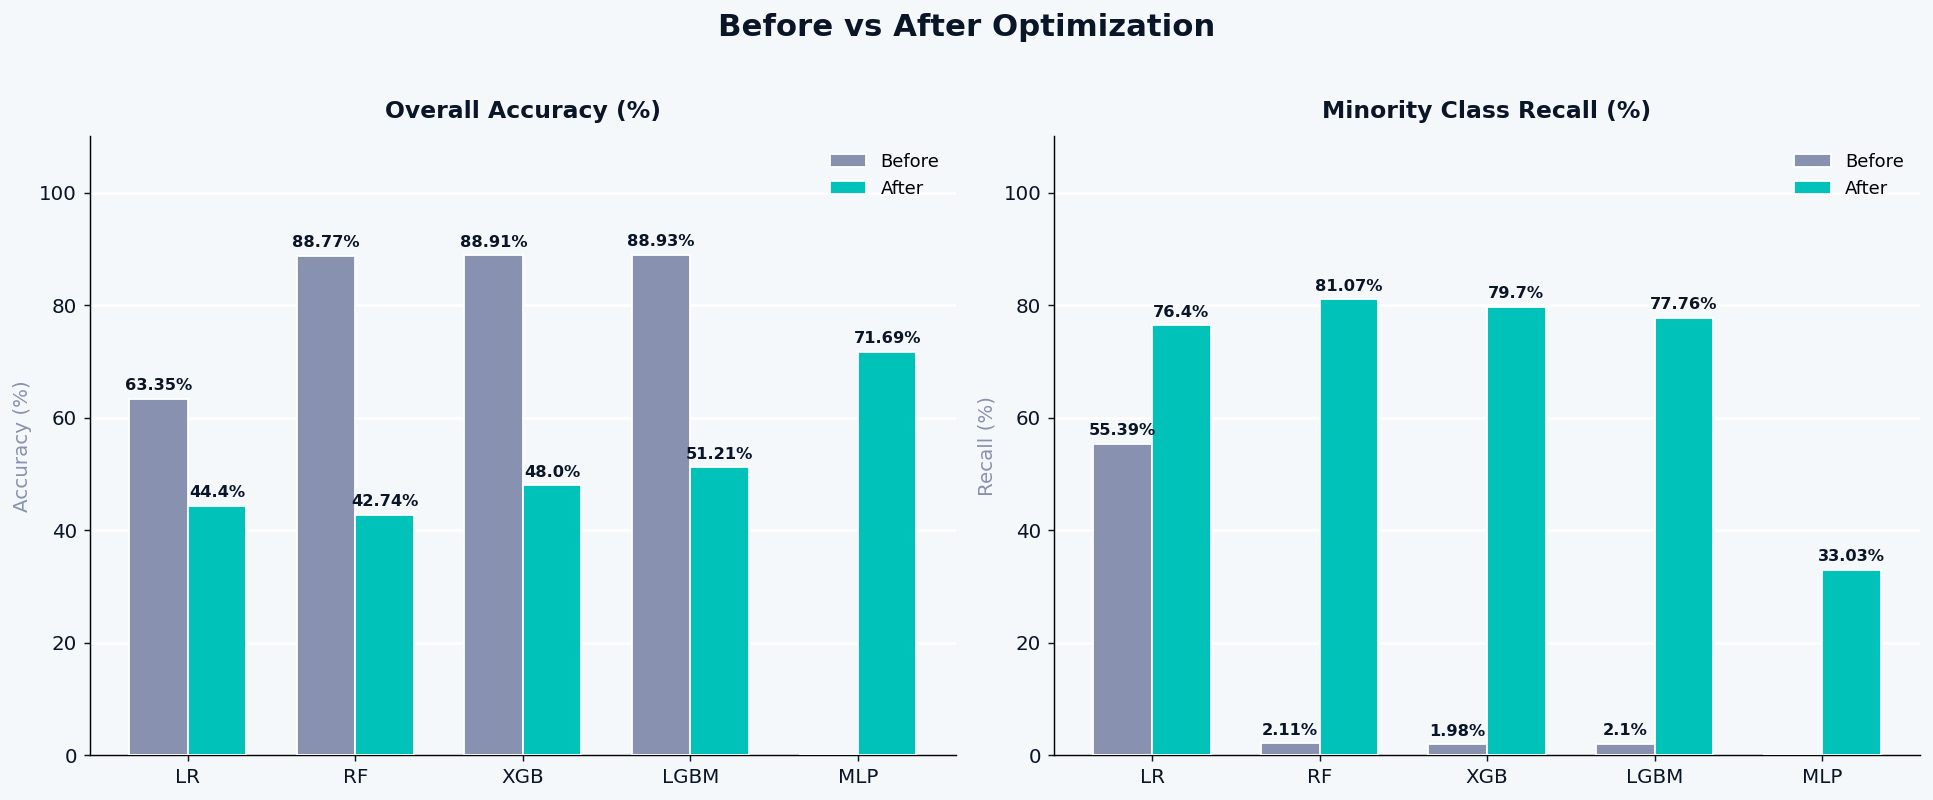

Saved -> optimization_comparison.png


In [ ]:
# Chart with all the 5 models to see before and after optimization
model_names = ['LR', 'RF', 'XGB', 'LGBM', 'MLP']

# Before values
acc_before = [63.35, 88.77, 88.91, 88.93, 0]
rec_before = [55.39,  2.11,  1.98,  2.10, 0]

acc_after = [
    round(accuracy_score(y_test, lr_preds_opt)  * 100, 2),
    round(accuracy_score(y_test, rf_preds_opt)  * 100, 2),
    round(accuracy_score(y_test, xgb_preds_opt) * 100, 2),
    round(accuracy_score(y_test, lgb_preds_opt) * 100, 2),
    round(accuracy_score(y_test, mlp_preds_opt) * 100, 2),
]
rec_after = [
    round(recall_score(y_test, lr_preds_opt)  * 100, 2),
    round(recall_score(y_test, rf_preds_opt)  * 100, 2),
    round(recall_score(y_test, xgb_preds_opt) * 100, 2),
    round(recall_score(y_test, lgb_preds_opt) * 100, 2),
    round(recall_score(y_test, mlp_preds_opt) * 100, 2),
]

x   = np.arange(len(model_names))
w   = 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor=LIGHT)
fig.suptitle('Before vs After Optimization', fontsize=17, fontweight='bold', color=NAVY, y=1.02)

for ax, before, after, title, ylabel in [
    (ax1, acc_before, acc_after, 'Overall Accuracy (%)',        'Accuracy (%)'),
    (ax2, rec_before, rec_after, 'Minority Class Recall (%)',   'Recall (%)'),
]:
    ax.set_facecolor(LIGHT)
    b1 = ax.bar(x - w / 2, before, w, label='Before', color=MUTED, edgecolor='white', zorder=3)
    b2 = ax.bar(x + w / 2, after,  w, label='After',  color=TEAL,  edgecolor='white', zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, color=NAVY, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', color=NAVY, pad=10)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.set_ylim(0, 110)
    ax.tick_params(colors=NAVY)
    ax.grid(axis='y', color='white', linewidth=1.5, zorder=0)
    ax.legend(fontsize=10, frameon=False)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 1.0,
                str(h) + '%',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=NAVY
            )

plt.tight_layout()
plt.savefig('optimization_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> optimization_comparison.png')


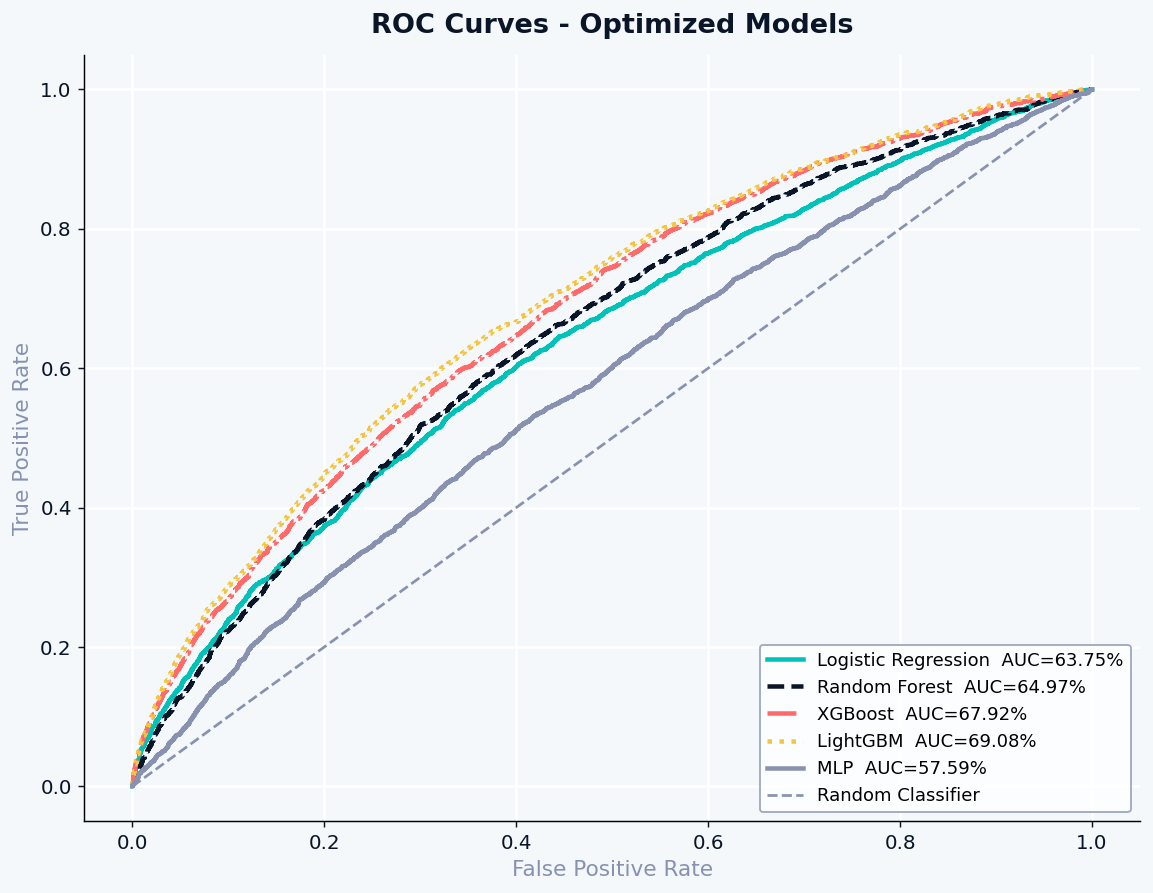

Saved -> roc_curves_optimized.png


In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(9, 7), facecolor=LIGHT)
ax.set_facecolor(LIGHT)
ax.set_title('ROC Curves - Optimized Models', fontsize=15, fontweight='bold', color=NAVY, pad=12)

models_roc = [
    ('Logistic Regression', lr_proba_opt,  TEAL,  '-'),
    ('Random Forest',       rf_proba_opt,  NAVY,  '--'),
    ('XGBoost',             xgb_proba_opt, CORAL, '-.'),
    ('LightGBM',            lgb_proba_opt, GOLD,  ':'),
    ('MLP',                 mlp_proba,     MUTED, '-'),
]

for label, proba, color, ls in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = round(roc_auc_score(y_test, proba) * 100, 2)
    ax.plot(fpr, tpr, color=color, lw=2.5, linestyle=ls,
            label=label + '  AUC=' + str(auc) + '%')

ax.plot([0, 1], [0, 1], color=MUTED, lw=1.5, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', color=MUTED, fontsize=12)
ax.set_ylabel('True Positive Rate', color=MUTED, fontsize=12)
ax.tick_params(colors=NAVY)
ax.legend(fontsize=10, frameon=True, facecolor='white', edgecolor=MUTED, loc='lower right')
ax.grid(color='white', linewidth=1.5)
plt.tight_layout()
plt.savefig('roc_curves_optimized.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> roc_curves_optimized.png')

**Feature Importance**

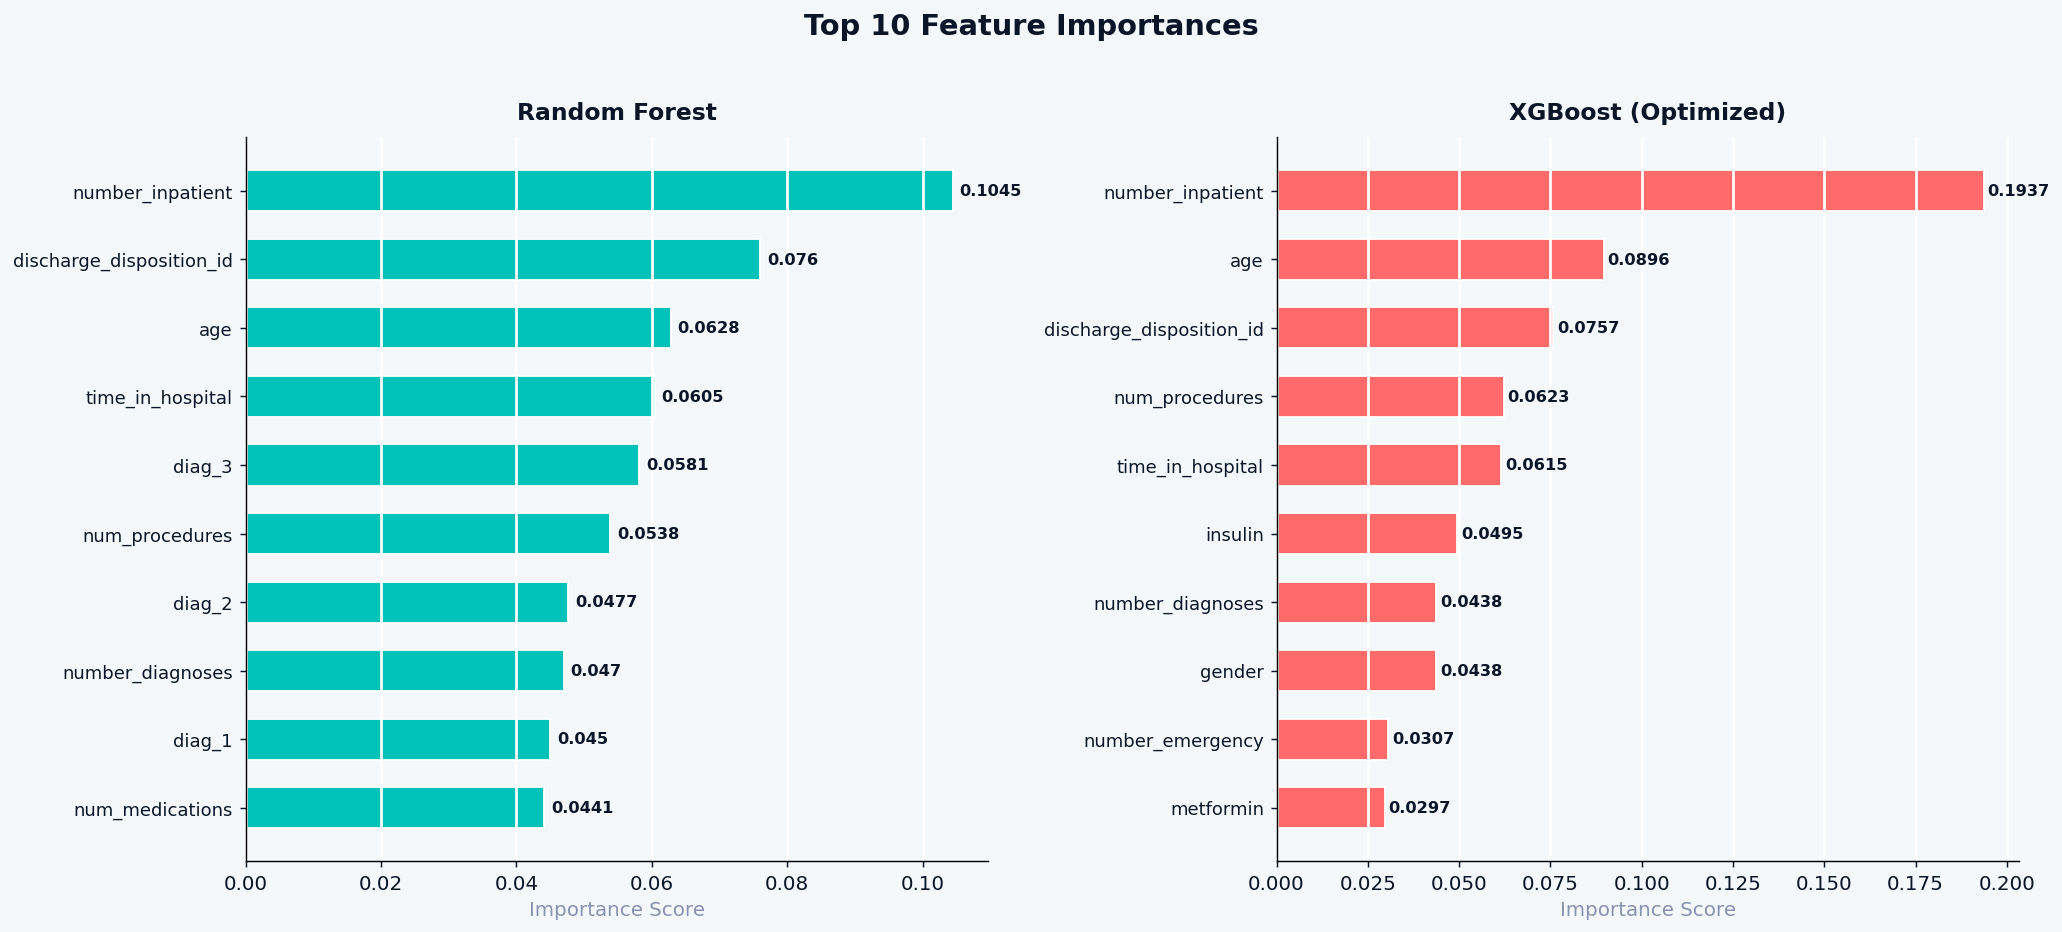

Saved -> feature_importance_chart.png


In [ ]:
#  Feature Importance Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor=LIGHT)
fig.suptitle('Top 10 Feature Importances', fontsize=16, fontweight='bold', color=NAVY, y=1.02)

rf_top = pd.Series(
    rf_model_balanced.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(10)

xgb_top = pd.Series(
    xgb_opt.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(10)

for ax, series, title, color in [
    (ax1, rf_top,  'Random Forest',  TEAL),
    (ax2, xgb_top, 'XGBoost (Optimized)', CORAL),
]:
    ax.set_facecolor(LIGHT)
    bars = ax.barh(range(len(series)), series.values,
                   color=color, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(series)))
    ax.set_yticklabels(series.index, fontsize=10, color=NAVY)
    ax.set_title(title, fontsize=13, fontweight='bold', color=NAVY, pad=10)
    ax.set_xlabel('Importance Score', color=MUTED)
    ax.tick_params(colors=NAVY)
    ax.grid(axis='x', color='white', linewidth=1.5)
    for bar, val in zip(bars, series.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                str(round(val, 4)), va='center', fontsize=9,
                fontweight='bold', color=NAVY)

plt.tight_layout()
plt.savefig('feature_importance_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> feature_importance_chart.png')


In [ ]:
# Which are the top 20 Feature importance (Random Forest)
rf_importance = pd.Series(
    rf_model_balanced.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(20)

,0
number_inpatient,0.104454
discharge_disposition_id,0.075963
age,0.062792
time_in_hospital,0.060453
diag_3,0.058136
num_procedures,0.053849
diag_2,0.047669
number_diagnoses,0.046960
diag_1,0.044997
num_medications,0.044071


**Model Comparison and Validation**

In [ ]:
# Model Comparison Table
# To check the model that performed the best for minority class prediction (accuracy and recallfro class 1)
results_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_preds_opt)  * 100, 2),
        round(accuracy_score(y_test, rf_preds_opt)  * 100, 2),
        round(accuracy_score(y_test, xgb_preds_opt) * 100, 2),
        round(accuracy_score(y_test, lgb_preds_opt) * 100, 2),
        round(accuracy_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'Recall (%)': [
        round(recall_score(y_test, lr_preds_opt)  * 100, 2),
        round(recall_score(y_test, rf_preds_opt)  * 100, 2),
        round(recall_score(y_test, xgb_preds_opt) * 100, 2),
        round(recall_score(y_test, lgb_preds_opt) * 100, 2),
        round(recall_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'Precision (%)': [
        round(precision_score(y_test, lr_preds_opt)  * 100, 2),
        round(precision_score(y_test, rf_preds_opt)  * 100, 2),
        round(precision_score(y_test, xgb_preds_opt) * 100, 2),
        round(precision_score(y_test, lgb_preds_opt) * 100, 2),
        round(precision_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'F1 (%)': [
        round(f1_score(y_test, lr_preds_opt)  * 100, 2),
        round(f1_score(y_test, rf_preds_opt)  * 100, 2),
        round(f1_score(y_test, xgb_preds_opt) * 100, 2),
        round(f1_score(y_test, lgb_preds_opt) * 100, 2),
        round(f1_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'ROC-AUC (%)': [
        round(roc_auc_score(y_test, lr_proba_opt)  * 100, 2),
        round(roc_auc_score(y_test, rf_proba_opt)  * 100, 2),
        round(roc_auc_score(y_test, xgb_proba_opt) * 100, 2),
        round(roc_auc_score(y_test, lgb_proba_opt) * 100, 2),
        round(roc_auc_score(y_test, mlp_proba)     * 100, 2),
    ],
}).set_index('Model')

results_final.style.highlight_max(color='#d4edda', axis=0)


,Accuracy (%),Recall (%),Precision (%),F1 (%),ROC-AUC (%)
Model,,,,,
Logistic Regression,44.400000,76.400000,13.860000,23.470000,63.750000
Random Forest,42.740000,81.070000,14.090000,24.010000,64.970000
XGBoost,48.000000,79.700000,15.170000,25.490000,67.920000
LightGBM,51.210000,77.760000,15.780000,26.240000,69.080000
MLP,71.690000,33.030000,15.030000,20.660000,57.590000


skip the following (will delete later)

In [ ]:
# Cross Validation
# To check the more reliable perfomance estimate (rather than a single train/test split)
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=500, class_weight='balanced'))
])

cv_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("Logistic Regression CV Accuracy:", cv_lr.mean())

Logistic Regression CV Accuracy: 0.6299194757256272


**Nonlinear and Deep Learning Models**

In [ ]:
# Neural Network (deep learning)
nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train on SMOTE-balanced training data
nn.fit(X_train_smote, y_train_smote, epochs=10, batch_size=256, verbose=1)

# Predict on the scaled test set
nn_preds = (nn.predict(X_test_scaled) > 0.5).astype(int)

print("Neural Network Accuracy:", accuracy_score(y_test, nn_preds))
print(classification_report(y_test, nn_preds))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6283 - loss: 0.6428
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6744 - loss: 0.6027
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6995 - loss: 0.5766
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7151 - loss: 0.5577
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7288 - loss: 0.5411
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7394 - loss: 0.5267
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7489 - loss: 0.5145
Epoch 8/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7547 - loss: 0.5037
Epoch 9/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7628 - loss: 0.4938
Epoch 10/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7689 - loss: 0.4836
637/637 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Neural Network Accuracy: 0.6469981330451017
              precision    recall  f1-score   support


In [ ]:
# Final Model Comparison — Optimized Results
results_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_preds_opt)  * 100, 2),
        round(accuracy_score(y_test, rf_preds_opt)  * 100, 2),
        round(accuracy_score(y_test, xgb_preds_opt) * 100, 2),
        round(accuracy_score(y_test, lgb_preds_opt) * 100, 2),
        round(accuracy_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'Recall — Class 1 (%)': [
        round(recall_score(y_test, lr_preds_opt)  * 100, 2),
        round(recall_score(y_test, rf_preds_opt)  * 100, 2),
        round(recall_score(y_test, xgb_preds_opt) * 100, 2),
        round(recall_score(y_test, lgb_preds_opt) * 100, 2),
        round(recall_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'ROC-AUC (%)': [63.75, 64.97, 67.92, 69.08, 57.59]
})
results_final


,Model,Accuracy (%),Recall — Class 1 (%),ROC-AUC (%)
0,Logistic Regression,44.40,76.40,63.75
1,Random Forest,42.74,81.07,64.97
2,XGBoost,48.00,79.70,67.92
3,LightGBM,51.21,77.76,69.08
4,MLP,71.69,33.03,57.59


In [ ]:
summary = pd.DataFrame({
    'Model': [
        'LR (Original)', 'RF (Original)', 'XGB (Original)', 'LGBM (Original)',
        'LR (Optimized)', 'RF (Optimized)', 'XGB (Optimized)', 'LGBM (Optimized)',
        'MLP'
    ],
    'Accuracy (%)': [
        63.65, 88.77, 88.94, 88.89,
        round(accuracy_score(y_test, lr_preds_opt) * 100, 2),
        round(accuracy_score(y_test, rf_preds_opt) * 100, 2),
        round(accuracy_score(y_test, xgb_preds_opt) * 100, 2),
        round(accuracy_score(y_test, lgb_preds_opt) * 100, 2),
        round(accuracy_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'Recall (%)': [
        55.39, 2.11, 1.98, 2.10,
        round(recall_score(y_test, lr_preds_opt) * 100, 2),
        round(recall_score(y_test, rf_preds_opt) * 100, 2),
        round(recall_score(y_test, xgb_preds_opt) * 100, 2),
        round(recall_score(y_test, lgb_preds_opt) * 100, 2),
        round(recall_score(y_test, mlp_preds_opt) * 100, 2),
    ],
    'F1 (%)': [
        23.47, 3.84, 3.66, 3.43,
        round(f1_score(y_test, lr_preds_opt) * 100, 2),
        round(f1_score(y_test, rf_preds_opt) * 100, 2),
        round(f1_score(y_test, xgb_preds_opt) * 100, 2),
        round(f1_score(y_test, lgb_preds_opt) * 100, 2),
        round(f1_score(y_test, mlp_preds_opt) * 100, 2),
    ],
})

print(summary.to_string(index=False))


           Model  Accuracy (%)  Recall (%)  F1 (%)
   LR (Original)         63.65       55.39   23.47
   RF (Original)         88.77        2.11    3.84
  XGB (Original)         88.94        1.98    3.66
 LGBM (Original)         88.89        2.10    3.43
  LR (Optimized)         44.40       76.40   23.47
  RF (Optimized)         42.74       81.07   24.01
 XGB (Optimized)         48.00       79.70   25.49
LGBM (Optimized)         51.21       77.76   26.24
             MLP         71.69       33.03   20.66


**Model Evaluation**

The first original models achieved high accuracy but with very low recall, which means that they rarely identifiedthe true 30‑day readmissions. The great part was after optimization because recall increased exponentially (around 81%); the models became much better at detecting high‑risk patients; however, the overall accuracy decreased.